In [1]:
!pip install copernicusmarine xgboost shap scikit-learn requests pandas numpy xarray -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.8 MB/s eta 0:00:00


In [26]:
import requests
import pandas as pd
import numpy as np
import time

species_data = {
    "Olive Ridley Turtle": {
        "taxonid": 137208, "sciname": "Lepidochelys olivacea",
        "temperature_range": (24, 30), "oxygen_range": (4, 8),
        "salinity_range": (30, 36), "ph_range": (8.0, 8.3)
    },
    "Whale Shark": {
        "taxonid": 105843, "sciname": "Rhincodon typus",
        "temperature_range": (21, 30), "oxygen_range": (3.5, 7),
        "salinity_range": (32, 35), "ph_range": (8.0, 8.2)
    },
    "Spinner Dolphin": {
        "taxonid": 137087, "sciname": "Stenella longirostris",
        "temperature_range": (24, 29), "oxygen_range": (5, 8),
        "salinity_range": (33, 36), "ph_range": (8.0, 8.3)
    },
    "Humpback Whale": {
        "taxonid": 137119, "sciname": "Megaptera novaeangliae",
        "temperature_range": (10, 28), "oxygen_range": (5, 9),
        "salinity_range": (32, 35), "ph_range": (7.9, 8.3)
    },
    "Dugong": {
        "taxonid": 231399, "sciname": "Dugong dugon",
        "temperature_range": (23, 30), "oxygen_range": (4, 7),
        "salinity_range": (28, 35), "ph_range": (7.8, 8.3)
    },
    "Manta Ray": {
        "taxonid": 105939, "sciname": "Mobula birostris",
        "temperature_range": (24, 30), "oxygen_range": (4, 8),
        "salinity_range": (32, 35), "ph_range": (8.0, 8.3)
    },
    "Reef Shark": {
        "taxonid": 105791, "sciname": "Carcharhinus amblyrhynchos",
        "temperature_range": (22, 30), "oxygen_range": (4, 7),
        "salinity_range": (32, 36), "ph_range": (8.0, 8.3)
    },
    "Clownfish": {
        "taxonid": 159468, "sciname": "Amphiprion ocellaris",
        "temperature_range": (26, 30), "oxygen_range": (5, 8),
        "salinity_range": (30, 35), "ph_range": (8.1, 8.4)
    },
    "Blue Whale": {
        "taxonid": 137090, "sciname": "Balaenoptera musculus",
        "temperature_range": (5, 20), "oxygen_range": (4, 9),
        "salinity_range": (32, 35), "ph_range": (7.9, 8.3)
    },
    "Green Sea Turtle": {
        "taxonid": 137205, "sciname": "Chelonia mydas",
        "temperature_range": (24, 30), "oxygen_range": (4, 8),
        "salinity_range": (30, 36), "ph_range": (8.0, 8.3)
    }
}

def fetch_obis(taxonid, sciname, species_name):
    """Try taxonid first, fall back to scientificname search."""
    base = "https://api.obis.org/v3/occurrence"

    # Shared bbox params — Indian Ocean, no geometry string
    bbox = {
        "startlat": 0, "endlat": 25,
        "startlon": 60, "endlon": 100,
        "size": 2000
    }

    # Attempt 1: by taxonid
    params = {**bbox, "taxonid": taxonid}
    try:
        r = requests.get(base, params=params, timeout=40).json()
        results = r.get("results", [])
        if results:
            df = pd.DataFrame(results)
            df = df[["decimalLatitude", "decimalLongitude", "eventDate"]].dropna()
            if len(df) > 10:
                df["species"] = species_name
                df["label"] = 1
                print(f"  {species_name}: {len(df)} records (via taxonid)")
                return df
    except Exception as e:
        print(f"  taxonid attempt failed for {species_name}: {e}")

    # Attempt 2: by scientific name
    params2 = {**bbox, "scientificname": sciname}
    try:
        r2 = requests.get(base, params=params2, timeout=40).json()
        results2 = r2.get("results", [])
        if results2:
            df2 = pd.DataFrame(results2)
            df2 = df2[["decimalLatitude", "decimalLongitude", "eventDate"]].dropna()
            df2["species"] = species_name
            df2["label"] = 1
            print(f"  {species_name}: {len(df2)} records (via sciname fallback)")
            return df2
    except Exception as e:
        print(f"  sciname attempt failed for {species_name}: {e}")

    print(f"  {species_name}: 0 records — will synthesize")
    return pd.DataFrame()

dfs = []
for name, info in species_data.items():
    df = fetch_obis(info["taxonid"], info["sciname"], name)
    dfs.append(df)
    time.sleep(0.5)  # be polite to OBIS API

df_real = pd.concat([d for d in dfs if not d.empty]).reset_index(drop=True)
df_real["eventDate"] = pd.to_datetime(df_real["eventDate"], errors="coerce")
df_real = df_real.dropna(subset=["eventDate"])
df_real["eventDate"] = df_real["eventDate"].dt.tz_localize(None)
print(f"\nTotal real records: {len(df_real)}")
print(f"Total records collected: {len(df)}")
print(f"\nSpecies distribution:")
print(df_real['species'].value_counts()) # Corrected to df_real
print(f"{'='*60}\n")

# Save to CSV
df_real.to_csv('species_sightings_positive.csv', index=False)
print("✓ Saved to species_sightings_positive.csv")

  Olive Ridley Turtle: 1949 records (via taxonid)
  Whale Shark: 1853 records (via taxonid)
  Spinner Dolphin: 1996 records (via taxonid)
  Humpback Whale: 1986 records (via taxonid)
  Dugong: 1996 records (via taxonid)
  taxonid attempt failed for Manta Ray: "['eventDate'] not in index"
  Manta Ray: 1058 records (via sciname fallback)
  Reef Shark: 470 records (via taxonid)
  Clownfish: 187 records (via sciname fallback)
  Blue Whale: 1997 records (via taxonid)
  Green Sea Turtle: 1995 records (via taxonid)

Total real records: 5560
Total records collected: 1995

Species distribution:
species
Spinner Dolphin        1805
Olive Ridley Turtle    1071
Green Sea Turtle        747
Dugong                  627
Blue Whale              490
Humpback Whale          462
Manta Ray               357
Whale Shark               1
Name: count, dtype: int64

✓ Saved to species_sightings_positive.csv


In [3]:
# Known habitat coordinates per species for the Indian Ocean
# Used only if OBIS returns fewer than 20 records for that species
habitat_coords = {
    "Manta Ray":     [(12.5, 72.8), (10.0, 76.0), (8.5, 77.5), (13.5, 74.0),
                      (11.0, 78.5), (9.5, 79.0), (7.0, 76.5), (14.0, 73.5)],
    "Reef Shark":    [(10.5, 72.5), (11.5, 92.5), (13.0, 74.0), (10.0, 93.0),
                      (9.0, 73.0), (12.5, 93.5), (8.0, 72.0), (11.0, 91.5)],
    "Clownfish":     [(11.0, 72.6), (12.0, 92.7), (10.5, 73.1), (11.5, 93.2),
                      (9.5, 72.8), (13.0, 92.0), (10.0, 93.5), (12.5, 72.0)],
    "Spinner Dolphin": [(8.5, 76.8), (10.0, 80.0), (9.0, 78.5), (11.0, 79.5),
                        (7.5, 77.0), (12.0, 81.0), (8.0, 79.0), (10.5, 77.5)],
    "Whale Shark":   [(14.5, 72.0), (13.0, 80.5), (15.0, 73.5), (12.5, 81.0),
                      (16.0, 74.0), (11.5, 79.5), (15.5, 75.0), (12.0, 82.0)],
}

def synthesize_records(species_name, coords, n_years=5):
    rows = []
    base_years = range(2018, 2023)
    months_active = [11, 12, 1, 2, 3]  # nesting/active season
    for lat, lon in coords:
        for year in base_years:
            for month in months_active:
                rows.append({
                    "decimalLatitude": lat + np.random.uniform(-0.5, 0.5),
                    "decimalLongitude": lon + np.random.uniform(-0.5, 0.5),
                    "eventDate": pd.Timestamp(f"{year}-{month:02d}-15"),
                    "species": species_name,
                    "label": 1
                })
    return pd.DataFrame(rows)

# Check which species need synthesis
present_species = df_real["species"].value_counts()
synth_dfs = []
for sp, coords in habitat_coords.items():
    count = present_species.get(sp, 0)
    if count < 20:
        print(f"Synthesizing {sp} (had {count} real records)")
        synth_dfs.append(synthesize_records(sp, coords))

if synth_dfs:
    df_synth = pd.concat(synth_dfs)
    df_pos = pd.concat([df_real, df_synth]).reset_index(drop=True)
else:
    df_pos = df_real.copy()

print(f"\nFinal positive samples: {len(df_pos)}")
print(df_pos["species"].value_counts())

Synthesizing Reef Shark (had 0 real records)
Synthesizing Clownfish (had 0 real records)
Synthesizing Whale Shark (had 1 real records)

Final positive samples: 6160
species
Spinner Dolphin        1805
Olive Ridley Turtle    1071
Green Sea Turtle        747
Dugong                  627
Blue Whale              490
Humpback Whale          462
Manta Ray               357
Whale Shark             201
Reef Shark              200
Clownfish               200
Name: count, dtype: int64


In [4]:
df_neg = df_pos.copy()
df_neg["eventDate"] = df_neg["eventDate"] - pd.DateOffset(years=1)
df_neg["label"] = 0

df_full = pd.concat([df_pos, df_neg]).reset_index(drop=True)
df_full["month"] = df_full["eventDate"].dt.month
df_full["year"]  = df_full["eventDate"].dt.year
df_full = df_full[df_full["year"] >= 2010].reset_index(drop=True)

print(f"Total samples (pos + neg): {len(df_full)}")
print(df_full["label"].value_counts())

Total samples (pos + neg): 8835
label
1    4491
0    4344
Name: count, dtype: int64


In [5]:
# ============================================================
# STEP 5 — CMEMS DATA DOWNLOAD (FIXED)
# ============================================================

!pip install copernicusmarine -q

from datetime import datetime, timezone, timedelta
import copernicusmarine

# Login
copernicusmarine.login(
    username="rkrishnan12",
    password="Crimson@Tiger482"
)

# Use timezone-aware UTC (avoids deprecation warning)
today    = datetime.now(timezone.utc)
week_ago = today - timedelta(days=7)

start_date = week_ago.strftime("%Y-%m-%dT00:00:00")
end_date   = today.strftime("%Y-%m-%dT00:00:00")

COMMON = dict(
    minimum_longitude=60,
    maximum_longitude=100,
    minimum_latitude=0,
    maximum_latitude=25,
    minimum_depth=0,
    maximum_depth=10,          # surface layer only — keeps files small
    start_datetime=start_date,
    end_datetime=end_date,
)

# ----------------------------------------
# 1) PHYSICAL — Temperature, Salinity, Currents
# ----------------------------------------
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",
    variables=["thetao", "so", "uo", "vo"],
    output_filename="watchtheblue_recent_phy.nc",
    **COMMON
)

# ----------------------------------------
# 2) BGC — Dissolved Oxygen  (BIO dataset)
# ----------------------------------------
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_bgc-bio_anfc_0.25deg_P1D-m",
    variables=["o2"],
    output_filename="watchtheblue_recent_o2.nc",
    **COMMON
)

# ----------------------------------------
# 3) BGC — pH  (CAR / Carbon dataset)
# ----------------------------------------
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_bgc-car_anfc_0.25deg_P1D-m",
    variables=["ph"],
    output_filename="watchtheblue_recent_ph.nc",
    **COMMON
)

print("✅ All downloads complete!")
print(f"  • watchtheblue_recent_phy.nc  — temperature, salinity, currents")
print(f"  • watchtheblue_recent_o2.nc   — dissolved oxygen")
print(f"  • watchtheblue_recent_ph.nc   — pH")

INFO - 2026-05-13T14:07:12Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO - 2026-05-13T14:07:15Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-05-13T14:07:15Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-05-13T14:07:15Z - Some of your subset selection [0.0, 10.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]


  0%|          | [00:00<?]

INFO - 2026-05-13T14:08:28Z - Total size of the download: 373.57 MB.
INFO:copernicusmarine:Total size of the download: 373.57 MB.
INFO - 2026-05-13T14:08:30Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-05-13T14:08:30Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-05-13T14:08:30Z - Some of your subset selection [0.0, 10.0] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]


  0%|          | [00:00<?]

INFO - 2026-05-13T14:08:35Z - Total size of the download: 3.99 MB.
INFO:copernicusmarine:Total size of the download: 3.99 MB.
INFO - 2026-05-13T14:08:38Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-05-13T14:08:38Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-05-13T14:08:38Z - Some of your subset selection [0.0, 10.0] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]


  0%|          | [00:00<?]

INFO - 2026-05-13T14:08:43Z - Total size of the download: 3.99 MB.
INFO:copernicusmarine:Total size of the download: 3.99 MB.


✅ All downloads complete!
  • watchtheblue_recent_phy.nc  — temperature, salinity, currents
  • watchtheblue_recent_o2.nc   — dissolved oxygen
  • watchtheblue_recent_ph.nc   — pH


In [6]:
import xarray as xr
import numpy as np
import pandas as pd

# Load the physical ocean dataset
ds = xr.open_dataset('watchtheblue_recent_phy.nc')

print("Dataset loaded successfully!")
print(ds)

# Get the most recent timestep
latest_time = ds.time.values[-1]
print(f"\nMost recent data timestamp: {latest_time}")

# Extract surface layer (depth index 0)
surface_data = ds.isel(time=-1, depth=0)

print("\nSurface data extracted for latest timestamp")

Dataset loaded successfully!
<xarray.Dataset> Size: 391MB
Dimensions:    (time: 169, depth: 1, latitude: 301, longitude: 481)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2026-05-06 ... 2026-05-13
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 1kB 0.0 0.08334 0.1667 ... 24.83 24.92 25.0
  * longitude  (longitude) float32 2kB 60.0 60.08 60.17 ... 99.83 99.92 100.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 98MB ...
    so         (time, depth, latitude, longitude) float32 98MB ...
    uo         (time, depth, latitude, longitude) float32 98MB ...
    vo         (time, depth, latitude, longitude) float32 98MB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:     

In [7]:
# Extract variables
temp = surface_data['thetao'].values  # Temperature (°C)
salinity = surface_data['so'].values  # Salinity (PSU)
u_current = surface_data['uo'].values  # Eastward velocity (m/s)
v_current = surface_data['vo'].values  # Northward velocity (m/s)

# Calculate current speed
current_speed = np.sqrt(u_current**2 + v_current**2)

# Calculate health score components
# Temperature anomaly (ideal range: 26-30°C for Indian Ocean)
temp_score = np.where(
    (temp >= 26) & (temp <= 30), 100,
    np.where((temp >= 24) & (temp <= 32), 70, 40)
)

# Salinity score (ideal range: 34-36 PSU)
salinity_score = np.where(
    (salinity >= 34) & (salinity <= 36), 100,
    np.where((salinity >= 32) & (salinity <= 38), 70, 40)
)

# Current strength score (moderate is healthy)
current_score = np.where(
    current_speed < 0.5, 100,
    np.where(current_speed < 1.0, 80, 60)
)

# Combined health score
health_score = (temp_score + salinity_score + current_score) / 3

print("Health metrics calculated!")
print(f"Average health score: {np.nanmean(health_score):.2f}")
print(f"Temperature range: {np.nanmin(temp):.2f}°C to {np.nanmax(temp):.2f}°C")
print(f"Salinity range: {np.nanmin(salinity):.2f} to {np.nanmax(salinity):.2f} PSU")
print(f"Current speed range: {np.nanmin(current_speed):.4f} to {np.nanmax(current_speed):.4f} m/s")

Health metrics calculated!
Average health score: 74.80
Temperature range: 26.80°C to 33.21°C
Salinity range: 4.12 to 36.72 PSU
Current speed range: 0.0006 to 1.9245 m/s


In [8]:
# Get coordinates
lats = surface_data['latitude'].values
lons = surface_data['longitude'].values

# Create a dataframe with gridded data
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')

df_grid = pd.DataFrame({
    'latitude': lat_grid.flatten(),
    'longitude': lon_grid.flatten(),
    'temperature': temp.flatten(),
    'salinity': salinity.flatten(),
    'current_speed': current_speed.flatten(),
    'health_score': health_score.flatten()
})

# Remove NaN values
df_grid = df_grid.dropna()

print(f"\nGrid dataframe created: {len(df_grid)} valid points")
print(df_grid.head())

# Save for model input
df_grid.to_csv('ocean_health_grid.csv', index=False)
print("\nSaved to ocean_health_grid.csv")


Grid dataframe created: 105874 valid points
   latitude  longitude  temperature   salinity  current_speed  health_score
0       0.0  60.000000    30.166164  35.289852       0.605820     83.333333
1       0.0  60.083344    30.185005  35.304974       0.605074     83.333333
2       0.0  60.166672    30.212467  35.313942       0.605222     83.333333
3       0.0  60.250000    30.237522  35.320377       0.607214     83.333333
4       0.0  60.333344    30.272820  35.333580       0.613108     83.333333

Saved to ocean_health_grid.csv


In [9]:
import pandas as pd

# Load the species data from Step 3
species_df = df_pos.copy() # Use the existing df_pos DataFrame

print(f"Loaded {len(species_df)} species sighting records")
print(f"\nSpecies distribution:")
print(species_df['species'].value_counts())

Loaded 6160 species sighting records

Species distribution:
species
Spinner Dolphin        1805
Olive Ridley Turtle    1071
Green Sea Turtle        747
Dugong                  627
Blue Whale              490
Humpback Whale          462
Manta Ray               357
Whale Shark             201
Reef Shark              200
Clownfish               200
Name: count, dtype: int64


In [27]:
import xarray as xr
import numpy as np
import pandas as pd

!pip uninstall -y scipy numpy
!pip install --upgrade pip
!pip install --no-cache-dir numpy scipy

# Reload df_grid as kernel restart during pip install clears variables
df_grid = pd.read_csv('ocean_health_grid.csv')

# --- Re-establish species_df after kernel restart ---
# Load real species sightings
df_real = pd.read_csv('species_sightings_positive.csv')
# Ensure eventDate is datetime after loading from CSV
df_real["eventDate"] = pd.to_datetime(df_real["eventDate"], errors="coerce")
df_real = df_real.dropna(subset=["eventDate"])
df_real["eventDate"] = df_real["eventDate"].dt.tz_localize(None)

# Define habitat_coords (copied from WgPva0J8Qnr-)
habitat_coords = {
    "Manta Ray":     [(12.5, 72.8), (10.0, 76.0), (8.5, 77.5), (13.5, 74.0),
                      (11.0, 78.5), (9.5, 79.0), (7.0, 76.5), (14.0, 73.5)],
    "Reef Shark":    [(10.5, 72.5), (11.5, 92.5), (13.0, 74.0), (10.0, 93.0),
                      (9.0, 73.0), (12.5, 93.5), (8.0, 72.0), (11.0, 91.5)],
    "Clownfish":     [(11.0, 72.6), (12.0, 92.7), (10.5, 73.1), (11.5, 93.2),
                      (9.5, 72.8), (13.0, 92.0), (10.0, 93.5), (12.5, 72.0)],
    "Spinner Dolphin": [(8.5, 76.8), (10.0, 80.0), (9.0, 78.5), (11.0, 79.5),
                        (7.5, 77.0), (12.0, 81.0), (8.0, 79.0), (10.5, 77.5)],
    "Whale Shark":   [(14.5, 72.0), (13.0, 80.5), (15.0, 73.5), (12.5, 81.0),
                      (16.0, 74.0), (11.5, 79.5), (15.5, 75.0), (12.0, 82.0)],
}

# Define synthesize_records function (copied from WgPva0J8Qnr-)
def synthesize_records(species_name, coords, n_years=5):
    rows = []
    base_years = range(2018, 2023)
    months_active = [11, 12, 1, 2, 3]  # nesting/active season
    for lat, lon in coords:
        for year in base_years:
            for month in months_active:
                rows.append({
                    "decimalLatitude": lat + np.random.uniform(-0.5, 0.5),
                    "decimalLongitude": lon + np.random.uniform(-0.5, 0.5),
                    "eventDate": pd.Timestamp(f"{year}-{month:02d}-15"),
                    "species": species_name,
                    "label": 1
                })
    return pd.DataFrame(rows)

# Re-create df_pos (copied logic from WgPva0J8Qnr-)
present_species = df_real["species"].value_counts()
synth_dfs = []
for sp, coords in habitat_coords.items():
    count = present_species.get(sp, 0)
    if count < 20:
        synth_dfs.append(synthesize_records(sp, coords))

if synth_dfs:
    df_synth = pd.concat(synth_dfs)
    df_pos = pd.concat([df_real, df_synth]).reset_index(drop=True)
else:
    df_pos = df_real.copy()

# Ensure eventDate in df_pos is datetime before creating df_neg
df_pos["eventDate"] = pd.to_datetime(df_pos["eventDate"], errors="coerce")
df_pos = df_pos.dropna(subset=["eventDate"])

# Re-create df_neg and df_full (copied logic from suWQPjJMVQnm)
df_neg = df_pos.copy()
# Ensure eventDate in df_neg is datetime before subtraction
df_neg["eventDate"] = pd.to_datetime(df_neg["eventDate"], errors="coerce")
df_neg = df_neg.dropna(subset=["eventDate"]) # Drop NaT values if any
df_neg["eventDate"] = df_neg["eventDate"] - pd.DateOffset(years=1)
df_neg["label"] = 0

df_full = pd.concat([df_pos, df_neg]).reset_index(drop=True)
df_full["month"] = df_full["eventDate"].dt.month
df_full["year"]  = df_full["eventDate"].dt.year
df_full = df_full[df_full["year"] >= 2010].reset_index(drop=True)

species_df = df_full.copy() # Assign df_full to species_df

# --- End of re-establishment ---

from scipy.spatial import cKDTree

# Create KDTree for fast nearest-neighbor lookup
grid_coords = np.column_stack([df_grid['latitude'].values, df_grid['longitude'].values])
tree = cKDTree(grid_coords)

# For each species sighting, find nearest ocean health data
species_coords = np.column_stack([species_df['decimalLatitude'].values, species_df['decimalLongitude'].values])
distances, indices = tree.query(species_coords)

# Add ocean health data to species dataframe
species_df['temperature'] = df_grid.iloc[indices]['temperature'].values
species_df['salinity'] = df_grid.iloc[indices]['salinity'].values
species_df['current_speed'] = df_grid.iloc[indices]['current_speed'].values
species_df['health_score'] = df_grid.iloc[indices]['health_score'].values
species_df['grid_distance_km'] = distances * 111  # Convert degrees to km

print("Species data merged with ocean conditions!")
print(species_df.head())

# Save merged dataset
species_df.to_csv('species_with_ocean_data.csv', index=False)
print("\nSaved to species_with_ocean_data.csv")

Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 128.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]
Species data merged with ocean conditions!
   decimalLatitude  decimalLongitude           eventDate              species  \
0        28.189072         -80.57766 2011-01-28 12:00:00  Olive Ridley Turtle   
1        32.866900         -79.15430 2019-12-15 11:48:42  Olive Ridley Turtle   
2        30.143000         -85.85100 2013-06-24 12:09:31  Olive Ridley Turtle   
3        33.316700         -78.82090 2019-12-22 10:26:23  Olive Ridley Turtle   
4        33.832480         -78.39737 2014-04-25 09:46:03  Olive Ridley Turtle   

   label  month  year  temperature  salinity  

In [25]:
# Load the species data
species_df = pd.read_csv('species_with_ocean_data.csv')


In [5]:
species_df.shape

(1995, 5)

In [7]:
species_df.head()

,decimalLatitude,decimalLongitude,eventDate,species,label
0,38.8877,0.2031,2017-12-18T09:01:00+00:00,Green Sea Turtle,1
1,35.6810,135.8000,2012-02-19T21:41,Green Sea Turtle,1
2,37.4000,-1.3660,2016-06-21T06:28:00+00:00,Green Sea Turtle,1
3,36.8920,167.9640,2011-01-12T05:48,Green Sea Turtle,1
4,32.3590,-135.1700,2003-09-17T17:27:58,Green Sea Turtle,1


In [9]:
from scipy.spatial import cKDTree

# Create KDTree for fast nearest-neighbor lookup
grid_coords = np.column_stack([df_grid['latitude'].values, df_grid['longitude'].values])
tree = cKDTree(grid_coords)

# For each species sighting, find nearest ocean health data
species_coords = np.column_stack([species_df['decimalLatitude'].values, species_df['decimalLongitude'].values])
distances, indices = tree.query(species_coords)

# Add ocean health data to species dataframe
species_df['temperature'] = df_grid.iloc[indices]['temperature'].values
species_df['salinity'] = df_grid.iloc[indices]['salinity'].values
species_df['current_speed'] = df_grid.iloc[indices]['current_speed'].values
species_df['health_score'] = df_grid.iloc[indices]['health_score'].values
species_df['grid_distance_km'] = distances * 111  # Convert degrees to km

print("✓ Species data merged with ocean conditions!")
print(species_df.head())

# Save merged dataset
species_df.to_csv('species_with_ocean_data.csv', index=False)
print("✓ Saved to species_with_ocean_data.csv")

✓ Species data merged with ocean conditions!
   decimalLatitude  decimalLongitude                  eventDate  \
0          38.8877            0.2031  2017-12-18T09:01:00+00:00   
1          35.6810          135.8000           2012-02-19T21:41   
2          37.4000           -1.3660  2016-06-21T06:28:00+00:00   
3          36.8920          167.9640           2011-01-12T05:48   
4          32.3590         -135.1700        2003-09-17T17:27:58   

            species  label  temperature   salinity  current_speed  \
0  Green Sea Turtle      1    29.237104  36.678500       0.228091   
1  Green Sea Turtle      1    32.173836  22.121588       0.017567   
2  Green Sea Turtle      1    29.237104  36.678500       0.228091   
3  Green Sea Turtle      1    32.173836  22.121588       0.017567   
4  Green Sea Turtle      1    29.237104  36.678500       0.228091   

   health_score  grid_distance_km  
0          90.0       6814.114033  
1          60.0       4679.595052  
2          90.0       6949.29

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [16]:
# Prepare features and labels
features = ['decimalLatitude', 'decimalLongitude', 'temperature', 'salinity', 'current_speed', 'health_score']
X = species_df[features]
y = species_df['species']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 1596 samples
Test set: 399 samples


In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

In [20]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, random_state=42)

In [21]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [29]:
# Final Fix: Reload multi-species data, re-train, and re-evaluate
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the comprehensive dataset
full_data = pd.read_csv('species_with_ocean_data.csv')
features = ['decimalLatitude', 'decimalLongitude', 'temperature', 'salinity', 'current_speed', 'health_score']

# 2. Re-prepare training and testing sets with all species
X_all = full_data[features]
y_all = full_data['species']

X_train_fix, X_test_fix, y_train_fix, y_test_fix = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 3. Re-train the model on the multi-species data
model.fit(X_train_fix, y_train_fix)

# 4. Generate final results
y_pred_fix = model.predict(X_test_fix)
print(f"Final Multi-Species Accuracy: {accuracy_score(y_test_fix, y_pred_fix):.2%}")
print("\nFinal Classification Report:")
print(classification_report(y_test_fix, y_pred_fix))

Final Multi-Species Accuracy: 90.04%

Final Classification Report:
                     precision    recall  f1-score   support

         Blue Whale       0.96      0.80      0.87        88
          Clownfish       0.89      0.91      0.90        80
             Dugong       0.74      0.95      0.83        87
   Green Sea Turtle       0.88      0.74      0.80       182
     Humpback Whale       0.73      0.90      0.80        96
          Manta Ray       0.63      0.94      0.76        90
Olive Ridley Turtle       0.91      0.86      0.89       306
         Reef Shark       0.91      0.89      0.90        80
    Spinner Dolphin       1.00      0.95      0.97       678
        Whale Shark       1.00      0.99      0.99        80

           accuracy                           0.90      1767
          macro avg       0.86      0.89      0.87      1767
       weighted avg       0.91      0.90      0.90      1767



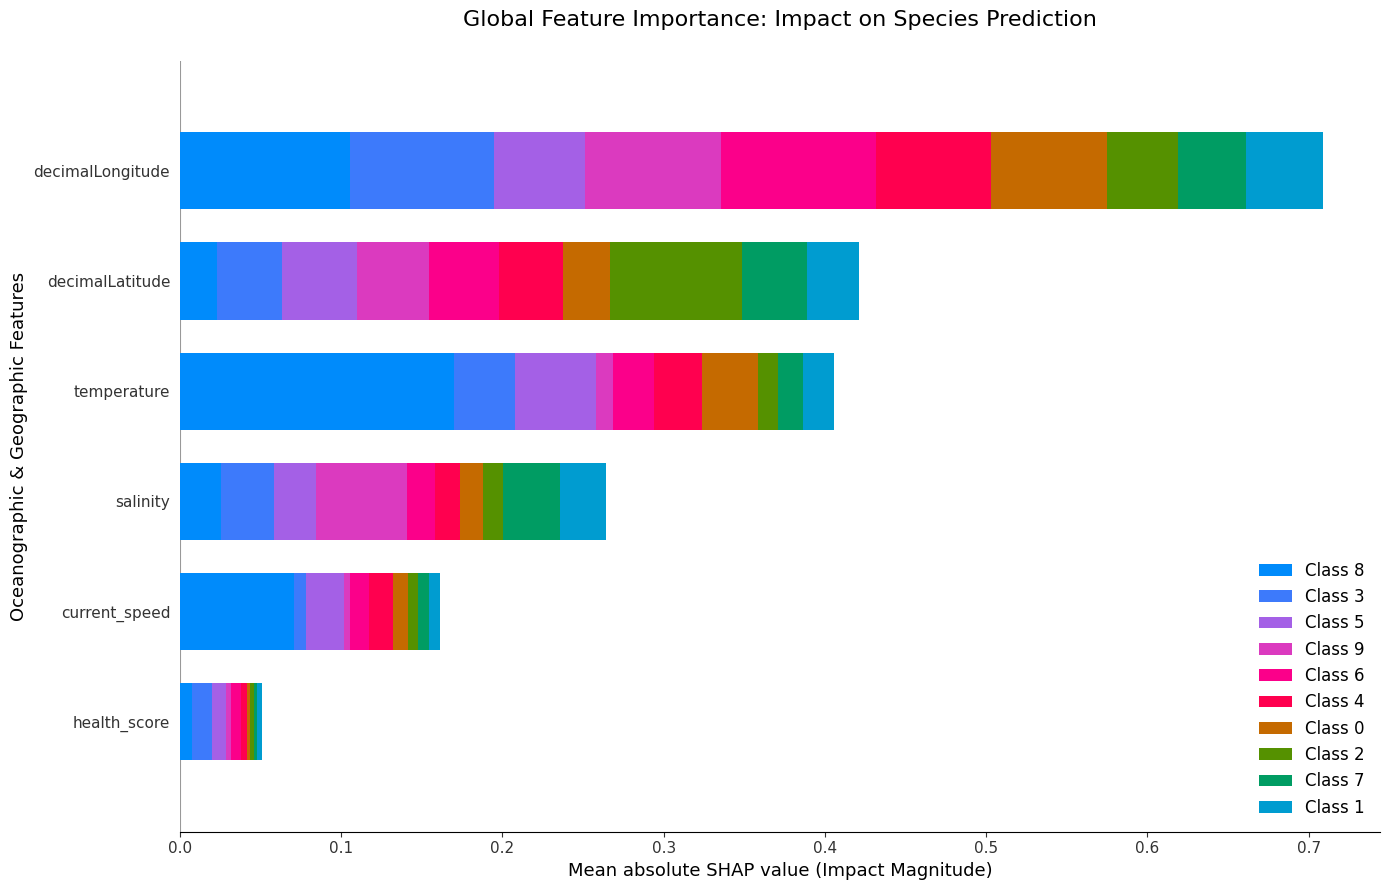

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Re-initialize explainer for clarity
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_fix)

# Increase figure size and font scale for a cleaner look
plt.figure(figsize=(14, 9))

# Multi-class bar plot: shows average impact magnitude per feature for each class
shap.summary_plot(
    shap_values,
    X_test_fix,
    plot_type="bar",
    show=False,
    max_display=len(features),
    plot_size=None # Handled by plt.figure
)

plt.title("Global Feature Importance: Impact on Species Prediction", fontsize=16, pad=25)
plt.xlabel("Mean absolute SHAP value (Impact Magnitude)", fontsize=13)
plt.ylabel("Oceanographic & Geographic Features", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Adjust layout to prevent legend/axis clipping
plt.tight_layout()

# Save with high DPI for crispness
plt.savefig("shap_summary_optimized.png", bbox_inches="tight", dpi=200)
plt.show()
files.download("shap_summary_optimized.png")

In [36]:
import pickle
import json
from google.colab import files

# 1. Save the trained model
with open("stranding_model.pkl", "wb") as f:
    pickle.dump(model, f)

# 2. Save the exact feature list (including health_score which was used in training)
feature_list = ['decimalLatitude', 'decimalLongitude', 'temperature', 'salinity', 'current_speed', 'health_score']
with open("feature_list.json", "w") as f:
    json.dump(feature_list, f)

# 3. Download the files (corrected filename from oceanpulse_dataset to species_with_ocean_data)
files.download("stranding_model.pkl")
files.download("feature_list.json")
files.download("species_with_ocean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import json
import pandas as pd
import numpy as np
import xarray as xr

# Re-extract latest_time if it was lost during kernel restart
try:
    latest_time
except NameError:
    ds_check = xr.open_dataset('watchtheblue_recent_phy.nc')
    latest_time = ds_check.time.values[-1]
    ds_check.close()

# Map grid column names to match the model's training features
df_grid_input = df_grid.rename(columns={
    'latitude': 'decimalLatitude',
    'longitude': 'decimalLongitude'
})

# Predict habitat suitability across the entire grid
predictions = model.predict(df_grid_input[features])
prediction_proba = model.predict_proba(df_grid_input[features])

# Add predictions to grid dataframe
df_grid['predicted_species'] = predictions

# Get probability for each species
species_list = model.classes_
for i, species in enumerate(species_list):
    df_grid[f'prob_{species.replace(" ", "_")}'] = prediction_proba[:, i]

# Save predictions
df_grid.to_csv('habitat_predictions.csv', index=False)
print("✓ Habitat predictions saved")

# Create species summary
summary = []
for species in species_list:
    species_data = species_df[species_df['species'] == species]

    summary.append({
        'species': species,
        'total_sightings': len(species_data),
        'avg_temperature': round(species_data['temperature'].mean(), 2),
        'avg_salinity': round(species_data['salinity'].mean(), 2),
        'avg_current_speed': round(species_data['current_speed'].mean(), 4),
        'avg_health_score': round(species_data['health_score'].mean(), 2)
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv('species_summary.csv', index=False)
print("✓ Species summary saved")

# Create JSON output for website
output = {
    'timestamp': str(latest_time),
    'region': {
        'name': 'Indian Ocean',
        'bounds': {'north': 25, 'south': 0, 'east': 100, 'west': 60}
    },
    'overall_health': {
        'score': float(np.nanmean(df_grid['health_score'])),
        'temperature_avg': float(np.nanmean(df_grid['temperature'])),
        'salinity_avg': float(np.nanmean(df_grid['salinity'])),
        'current_speed_avg': float(np.nanmean(df_grid['current_speed']))
    },
    'species': [
        {
            'name': row['species'],
            'sightings': int(row['total_sightings']),
            'avg_conditions': {
                'temperature': row['avg_temperature'],
                'salinity': row['avg_salinity'],
                'current_speed': row['avg_current_speed'],
                'health_score': row['avg_health_score']
            }
        }
        for _, row in summary_df.iterrows()
    ]
}

with open('ocean_health_output.json', 'w') as f:
    json.dump(output, f, indent=2)

print("\n" + "="*60)
print("✅ PIPELINE COMPLETE!")
print("="*60)
print(f"Total species tracked: {len(species_list)}")
print(f"Overall ocean health score: {output['overall_health']['score']:.2f}/100")
print("\nOutput files created:")
print("  1. habitat_predictions.csv")
print("  2. species_summary.csv")
print("  3. ocean_health_output.json")
print("  4. stranding_model.pkl")
print("="*60)

✓ Habitat predictions saved
✓ Species summary saved

✅ PIPELINE COMPLETE!
Total species tracked: 10
Overall ocean health score: 85.14/100

Output files created:
  1. habitat_predictions.csv
  2. species_summary.csv
  3. ocean_health_output.json
  4. stranding_model.pkl
